# FeedForward neural network: AlexNet

## Imports

In [1]:
from pathlib import Path
from matplotlib import pyplot
from matplotlib import gridspec
from PIL import Image
from torch import nn
from os import listdir
from os.path import isfile, join

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optimizer
import math
import torchvision
import pandas as pd

## Preparing the data

(499, 375)


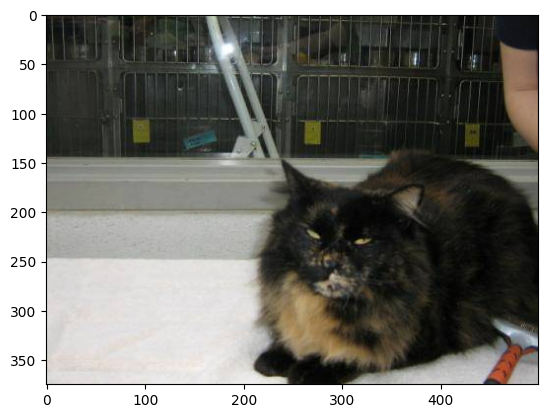

In [2]:
DATA_PATH = Path("../../data")
PATH = DATA_PATH / "cnd"

img = Image.open(PATH/"training_set/cats/cat.150.jpg")
print(img.size)

pyplot.imshow(img)
pyplot.show()

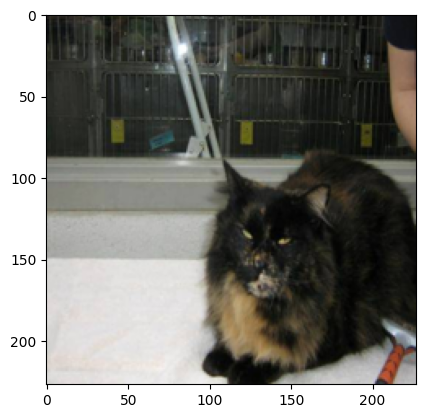

In [3]:
def scale_resize_image(image):
    resize_transform = torchvision.transforms.Resize((227, 227), interpolation=torchvision.transforms.InterpolationMode.BICUBIC)
    image = np.array(resize_transform.forward(image))
    return image

def get_valid_image(path):
    img = Image.open(path)
    val = scale_resize_image(img)
    val = np.moveaxis(val, -1, 0) # needed to move the channel to the first spot
    # val = np.expand_dims(val, 0)
    return val

val = scale_resize_image(img)
pyplot.imshow(val)
pyplot.show()

In [4]:
dataset_X = []
dataset_Y = []
for f in listdir(PATH/"training_set/cats"):
    if isfile(join(PATH/"training_set/cats", f)) and f[-4:] == ".jpg":
        dataset_X.append(torch.tensor(get_valid_image(PATH/"training_set/cats"/f)).to(torch.float32))
        dataset_Y.append(torch.tensor((1,0)).to(torch.float32))
for f in listdir(PATH/"training_set/dogs"):
    if isfile(join(PATH/"training_set/dogs", f)) and f[-4:] == ".jpg":
        dataset_X.append(torch.tensor(get_valid_image(PATH/"training_set/dogs"/f)).to(torch.float32))
        dataset_Y.append(torch.tensor((0,1)).to(torch.float32))

df = pd.DataFrame(data={"image":dataset_X, "label":dataset_Y})
df = df.sample(frac=1).reset_index(drop=True)

In [5]:
df.head()

,image,label
0,"[[[tensor(153.), tensor(173.), tensor(97.), te...","[tensor(0.), tensor(1.)]"
1,"[[[tensor(2.), tensor(2.), tensor(2.), tensor(...","[tensor(1.), tensor(0.)]"
2,"[[[tensor(54.), tensor(59.), tensor(64.), tens...","[tensor(1.), tensor(0.)]"
3,"[[[tensor(126.), tensor(125.), tensor(124.), t...","[tensor(1.), tensor(0.)]"
4,"[[[tensor(119.), tensor(125.), tensor(131.), t...","[tensor(0.), tensor(1.)]"


## Feedforward Neural Network

In [6]:
class AlexNet(nn.Module):
    def __init__(self):
        super(AlexNet, self).__init__()
        # Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4)
        self.conv2 = nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(9216, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, 2)

        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.dropout = nn.Dropout(p=0.5)
        
    # x represents our data
    def forward(self, x):
        # Layer 1
        x = nn.functional.relu(self.conv1(x))
        x = self.maxpool1(x)
        # Layer 2
        x = nn.functional.relu(self.conv2(x))
        x = self.maxpool2(x)
        # Layer 3
        x = nn.functional.relu(self.conv3(x))
        x = nn.functional.relu(self.conv4(x))
        x = nn.functional.relu(self.conv5(x))
        x = self.maxpool3(x)
        x = torch.flatten(x)
        # Layer 4
        x = self.dropout(nn.functional.relu(self.fc1(x)))
        x = self.dropout(nn.functional.relu(self.fc2(x)))
        x = self.fc3(x)

        # Apply softmax to x
        output = x

        return output

In [7]:
class CustomNet(nn.Module):
    def __init__(self):
        super(CustomNet, self).__init__()
        # Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=6, padding=1, stride=2)
        self.conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=6, padding=1, stride=5)

        self.avgpool1 = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)
        self.avgpool2 = nn.AvgPool2d(kernel_size=4, stride=3, padding=1)

        self.fc1 = nn.Linear(in_features=1176, out_features=512)
        self.fc2 = nn.Linear(in_features=512, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=2)
        
    # x represents our data
    def forward(self, x):
        # Layer 1
        x = nn.functional.relu(self.conv1(x)) # 227x227x3 -> 112x112x12
        x = self.avgpool1(x) #112x112x12 -> 112x112x12

        # Layer 2
        x = nn.functional.relu(self.conv2(x)) # 112x112x12 -> 22x22x24
        x = self.avgpool2(x)
        x = torch.flatten(x)

        # Layer 3
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x = self.fc3(x)

        return x

## Training the model

In [8]:
custom_net = CustomNet()
criterion = nn.CrossEntropyLoss()
opt = optimizer.SGD(custom_net.parameters(),lr=0.001)
# opt = optimizer.Adam(custom_net.parameters(),lr=0.0001)

# X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(df.image, df.label, test_size=0.2, random_state=10, shuffle=True)
# X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(df.image, df.label, test_size=0.2, random_state=10, shuffle=True)
samples = df.sample(int(0.8*len(df)))
validation = pd.concat([df,samples]).drop_duplicates(keep=False)

validation_loss = []
training_loss = []
for epoch in range(20):
    t_loss = 0
    running_loss = 0
    i = 0
    for _, row in samples.iterrows():
        opt.zero_grad()

        outputs = custom_net(row.image)
        loss = criterion(outputs, row.label)
        loss.backward()
        opt.step()

        running_loss += loss.item()
        t_loss += loss.item()
        # if i == 10:
        #     break
        if i % 500 == 499:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 500:.3f}')
            print(torch.softmax(outputs, 0), row.label)
            running_loss = 0.0
        i += 1
    training_loss.append(t_loss/i)
    j = 0
    with torch.no_grad():
        val = 0
        for _, row in validation.iterrows():
            outputs = custom_net(row.image)
            loss = criterion(outputs, row.label)
            val += loss.item()
            j += 1
        validation_loss.append(val/j)
        
        

[1,   500] loss: 0.784
tensor([0.5104, 0.4896], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  1000] loss: 0.695
tensor([0.5118, 0.4882], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  1500] loss: 0.694
tensor([0.4887, 0.5113], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  2000] loss: 0.693
tensor([0.5064, 0.4936], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  2500] loss: 0.694
tensor([0.5039, 0.4961], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  3000] loss: 0.689
tensor([0.3973, 0.6027], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  3500] loss: 0.693
tensor([0.4950, 0.5050], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  4000] loss: 0.682
tensor([0.5035, 0.4965], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  4500] loss: 0.687
tensor([0.4999, 0.5001], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  5000] loss: 0.689
tensor([0.4474, 0.5526], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  5500] loss: 0.682
tensor([0.4000, 0.6000], grad_fn=<SoftmaxBackwa

In [10]:
net = AlexNet()
# net = CustomNet()
criterion = nn.CrossEntropyLoss()
# opt = optimizer.SGD(net.parameters(),lr=0.001)
opt = optimizer.SGD(net.parameters(),lr=0.001, momentum=0.1)

# X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(df.image, df.label, test_size=0.2, random_state=10, shuffle=True)
# X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(dataset_X, dataset_Y, test_size=0.2, random_state=10, shuffle=True)
samples = df.sample(int(0.8*len(df)))
validation = pd.concat([df,samples]).drop_duplicates(keep=False)

validation_loss_alex = []
training_loss_alex = []
for epoch in range(10):
    t_loss = 0
    running_loss = 0
    i = 0
    for _, row in samples.iterrows():
        opt.zero_grad()

        outputs = net(row.image)
        loss = criterion(outputs, row.label)
        loss.backward()
        opt.step()
        # print(outputs, Y_train[i])

        # print statistics
        # with torch.no_grad():
        #     outputs = AlexNet(row)
        #     loss = criterion(outputs, Y_train[i])
        running_loss += loss.item()
        t_loss += loss.item()
        # if i == 10:
        #     break
        if i % 500 == 499:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 500:.3f}')
            print(torch.softmax(outputs, 0), row.label)
            running_loss = 0.0
        i+=1
    training_loss_alex.append(t_loss/i)
    j=0
    with torch.no_grad():
        val = 0
        for _, row in validation.iterrows():
            outputs = net(row.image)
            loss = criterion(outputs, row.label)
            val += loss.item()
            j+=1
        validation_loss_alex.append(val/j)
        

[1,   500] loss: 0.730
tensor([0.4739, 0.5261], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  1000] loss: 0.701
tensor([0.4868, 0.5132], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  1500] loss: 0.694
tensor([0.4846, 0.5154], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  2000] loss: 0.689
tensor([0.5222, 0.4778], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  2500] loss: 0.693
tensor([0.5176, 0.4824], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  3000] loss: 0.690
tensor([0.4523, 0.5477], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  3500] loss: 0.687
tensor([0.4787, 0.5213], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  4000] loss: 0.688
tensor([0.5041, 0.4959], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  4500] loss: 0.689
tensor([0.5319, 0.4681], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  5000] loss: 0.680
tensor([0.2800, 0.7200], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  5500] loss: 0.674
tensor([0.4853, 0.5147], grad_fn=<SoftmaxBackwa

## Analysis of models

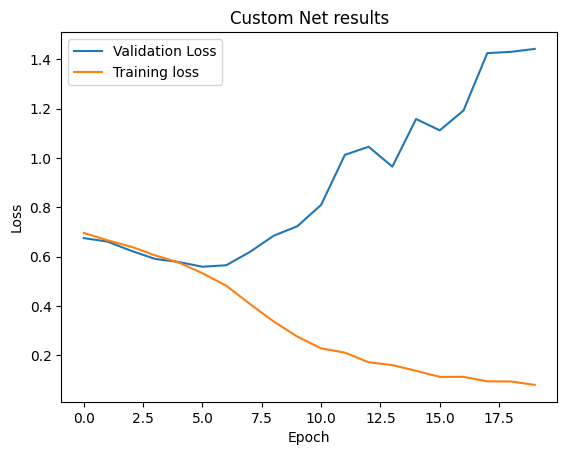

In [9]:
pyplot.plot(validation_loss, label="Validation Loss")
pyplot.plot(training_loss, label="Training loss")
pyplot.ylabel("Loss")
pyplot.xlabel("Epoch")
pyplot.title("Custom Net results")
pyplot.legend()

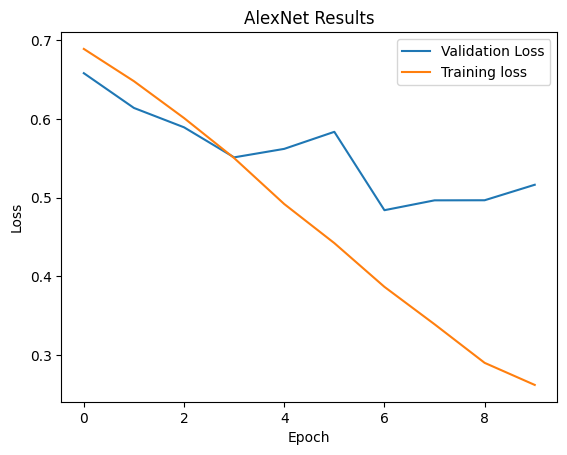

In [11]:
pyplot.plot(validation_loss_alex, label="Validation Loss")
pyplot.plot(training_loss_alex, label="Training loss")
pyplot.ylabel("Loss")
pyplot.xlabel("Epoch")
pyplot.title("AlexNet Results")
pyplot.legend()

In [13]:
save_path = './AlexNET_2.pth'
torch.save(net.state_dict(), save_path)
save_path = './CustomNet.pth'
torch.save(custom_net.state_dict(), save_path)

In [390]:
model_path = './AlexNET.pth'
new_net = AlexNet()
new_net.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

In [15]:
X_test = []
Y_test = []
path_test = []
for f in listdir(PATH/"test_set/cats"):
    if isfile(join(PATH/"test_set/cats", f)) and f[-4:] == ".jpg":
        X_test.append(torch.tensor(get_valid_image(PATH/"test_set/cats"/f)).to(torch.float32))
        Y_test.append(torch.tensor((1,0)).to(torch.float32))
        path_test.append(PATH/"test_set/cats"/f)
for f in listdir(PATH/"test_set/dogs"):
    if isfile(join(PATH/"test_set/dogs", f)) and f[-4:] == ".jpg":
        X_test.append(torch.tensor(get_valid_image(PATH/"test_set/dogs"/f)).to(torch.float32))
        Y_test.append(torch.tensor((0,1)).to(torch.float32))
        path_test.append(PATH/"test_set/dogs"/f)

df_test = pd.DataFrame(data={"image":X_test, "label":Y_test, "path":path_test})
df_test = df_test.sample(frac=1).reset_index(drop=True)

/Users/jgrguric/Repos/ml_tut/ML-101/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


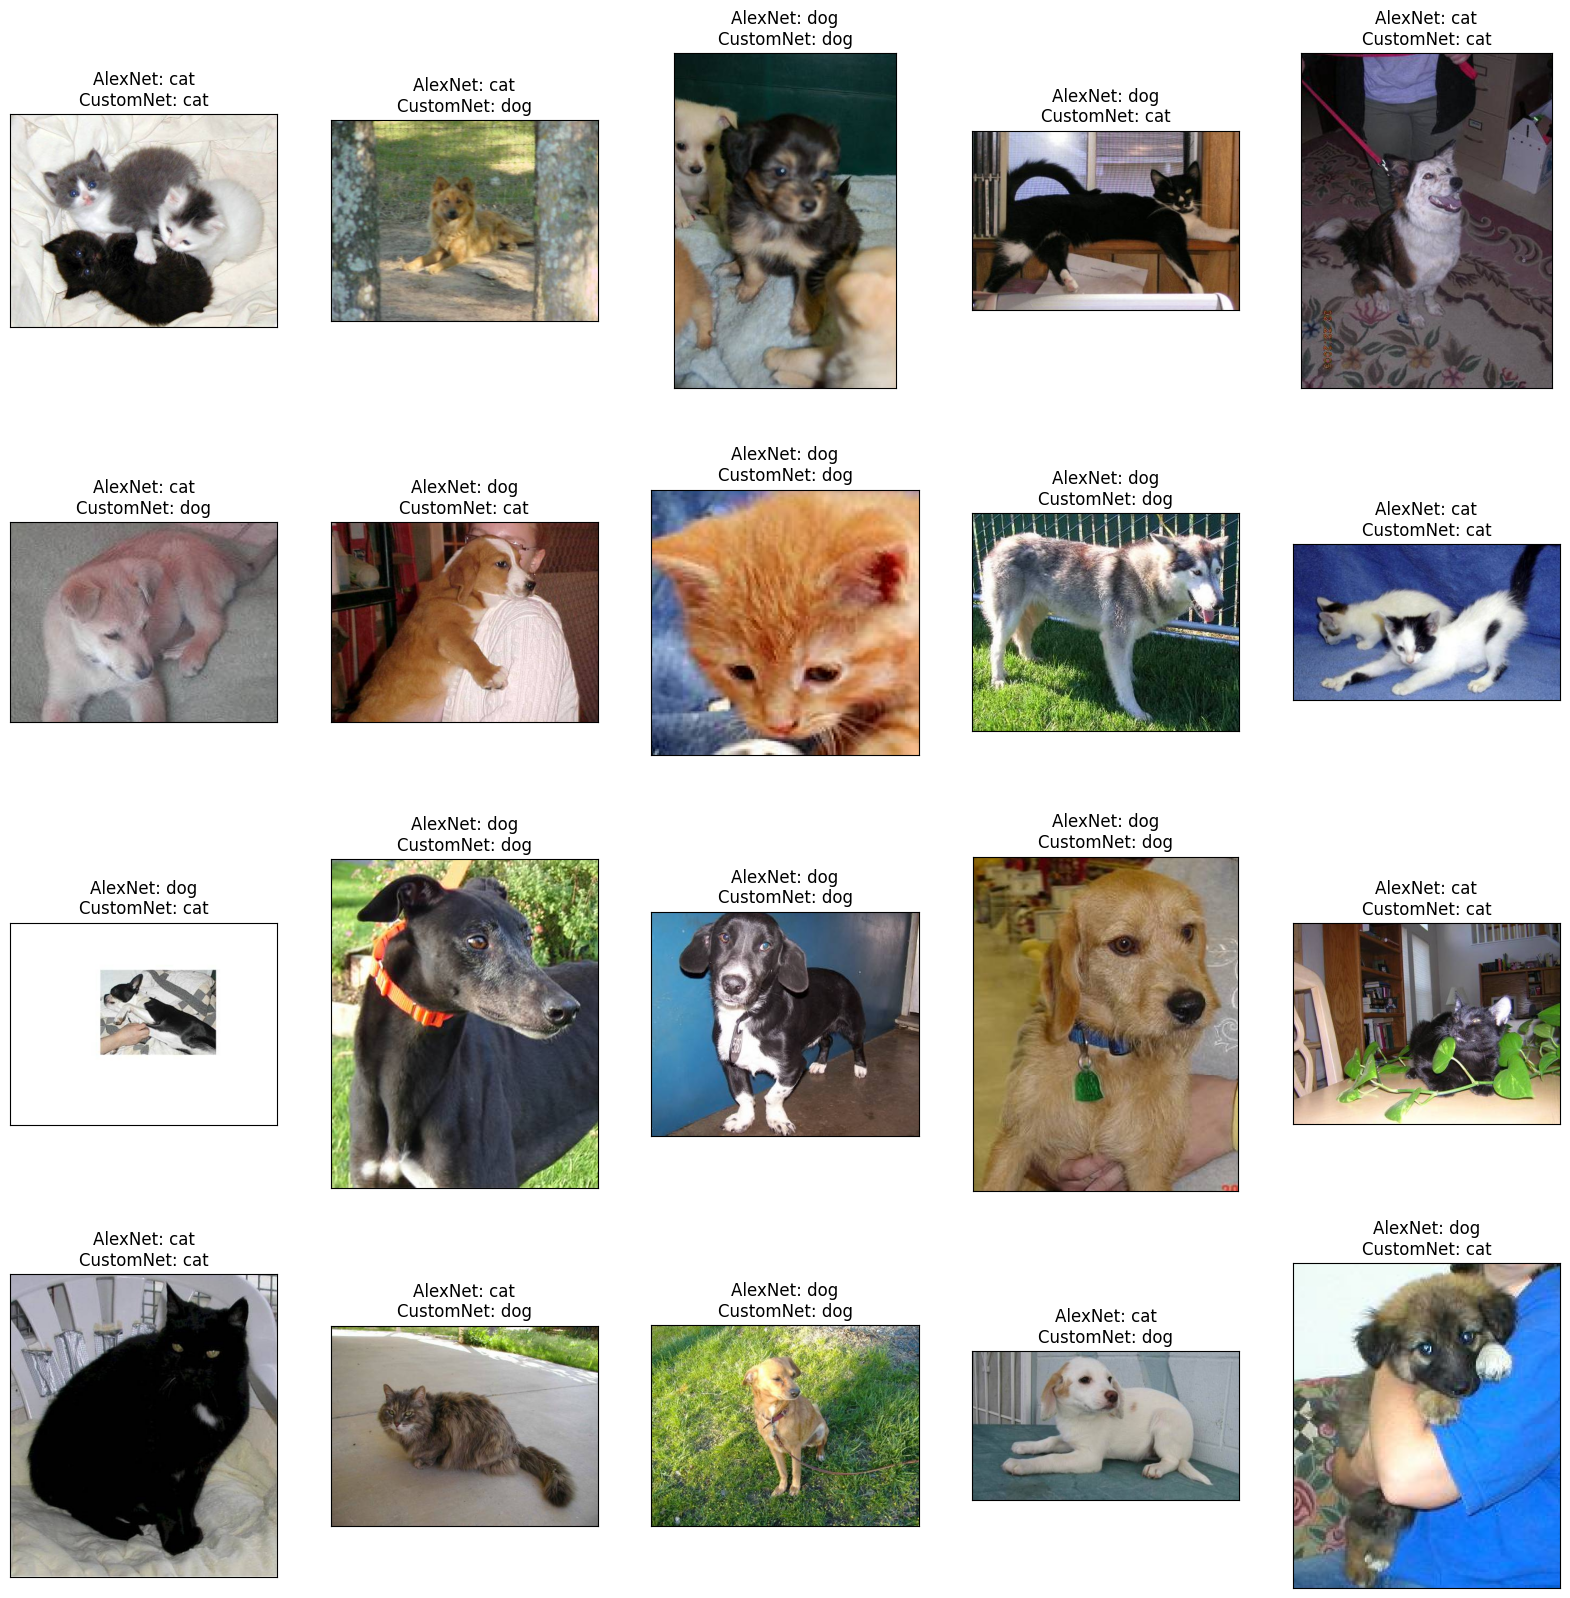

In [17]:
samples = df_test.sample(20)

x = []
title = []
for index, sample in samples.iterrows():
    x.append(sample.path)
    title.append("AlexNet: dog") if torch.argmax(net(sample.image)) else title.append("AlexNet: cat")
    title[-1] = f"{title[-1]}\nCustomNet: dog" if torch.argmax(custom_net(sample.image)) else f"{title[-1]}\nCustomNet: cat"
    
grid_size_x = math.floor((len(x))**(1/2))
grid_size_y = math.ceil((len(x))/grid_size_x)  
gs = gridspec.GridSpec(grid_size_x, grid_size_y)   
# gs.update(bottom=0.1)
# gs.update(top=0.55)
fig = pyplot.figure(constrained_layout = True)
fig.set_figwidth(20)
fig.set_figheight(20)
# Process image
for i, im in enumerate(x):
    ax = fig.add_subplot(gs[(i)//grid_size_y, (i)%grid_size_y])
    ax.imshow(Image.open(im))
    ax.set_title(title[i])
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)



pyplot.show()

In [29]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for _, sample in df_test.iterrows():
        # calculate outputs by running images through the network
        outputs = net(sample.image)
        predicted = torch.argmax(outputs)
        total += 1
        correct += 1 if predicted == torch.argmax(sample.label) else 0
print(f"Accuracy is {correct/total}")

Accuracy is 0.7938704893722195


In [27]:
true_positive = 0
true_negative = 0
false_positive = 0
false_negative = 0

with torch.no_grad():
    n=0
    for _, sample in df_test.iterrows():
        prediction = torch.softmax(net(sample.image), 0)
        n += 1
        if torch.argmax(prediction) == torch.argmax(sample.label):
            if torch.argmax(prediction):
                true_positive += 1
            else:
                true_negative += 1
        else:
            if torch.argmax(prediction):
                false_positive += 1
            else:
                false_negative += 1

print("Accuracy rate: ", (true_positive + true_negative)/n)
print("Total number of guesses: ", n)
print("Confusion matrix:")
print(f"True positive: {true_positive} \t False negative: {false_negative}")
print(f"False positive: {false_positive} \t True negative: {true_negative}")
        

Accuracy rate:  0.7948591201186357
Total number of guesses:  2023
Confusion matrix:
True positive: 765 	 False negative: 247
False positive: 168 	 True negative: 843
